<a href="https://colab.research.google.com/github/shivm1908/NEUR-3002/blob/main/HW4ClusteringActivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!pip install spacy scikit-learn matplotlib seaborn ipywidgets
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 23.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "1"


📊 Cluster Assignments:
      Word  Cluster     PCA_1     PCA_2
0    apple        2  3.887338 -1.202152
1   banana        2  3.887338 -1.202152
2    grape        2  3.822902 -1.082758
3     king        1 -4.118342 -3.238628
4    queen        0 -2.763273  1.236078
5   prince        1 -4.118342 -3.238628
6   soccer        0 -2.128488  4.082914
7   cookie        2  2.243509  0.753200
8  college        3 -0.712641  3.892127


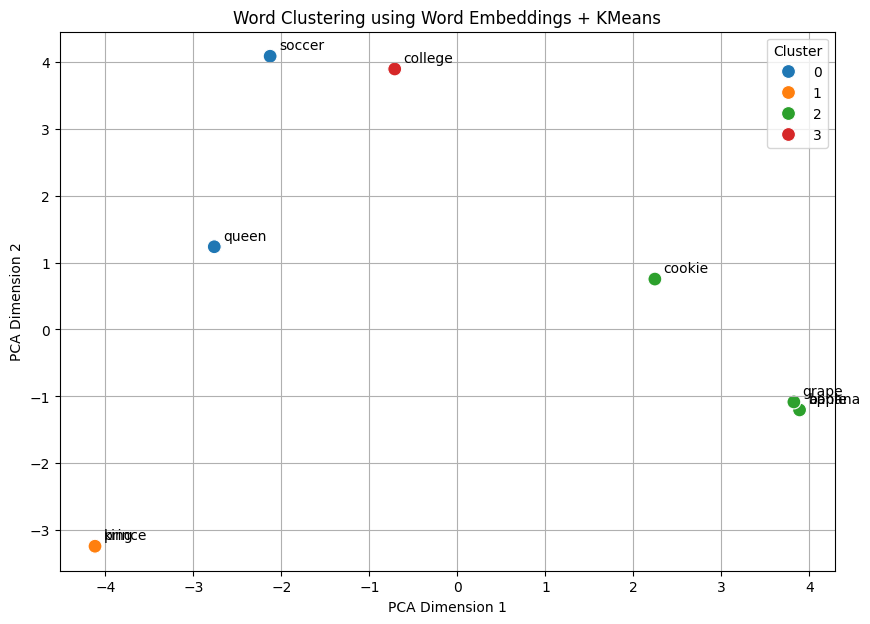

In [12]:
# 📦 Imports
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd

# 🧠 Load spaCy's medium English model (includes word vectors)
nlp = spacy.load("en_core_web_md")

# ✍️ Input: List of words to cluster
words = ["apple", "banana", "grape", "king", "queen", "prince", "soccer", "cookie", "college"]

# 🔢 Extract word vectors
word_vectors = [nlp(word).vector for word in words]

# ⚙️ Clustering using KMeans
k = 4  # Number of clusters — adjust as needed
kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
labels = kmeans.fit_predict(word_vectors)

# 🔍 Reduce dimensions for visualization (2D)
pca = PCA(n_components=2)
points_2d = pca.fit_transform(word_vectors)

# 🧾 Show cluster assignments as a table
df = pd.DataFrame({
    "Word": words,
    "Cluster": labels,
    "PCA_1": points_2d[:, 0],
    "PCA_2": points_2d[:, 1]
})
print("📊 Cluster Assignments:")
print(df)

# 🎨 Plot the clustered words
plt.figure(figsize=(10, 7))
sns.scatterplot(x=points_2d[:, 0], y=points_2d[:, 1], hue=labels, palette="tab10", s=100)

# Annotate each point with the word
for i, word in enumerate(words):
    plt.text(points_2d[i, 0]+0.1, points_2d[i, 1]+0.1, word)

plt.title("Word Clustering using Word Embeddings + KMeans")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

Similarity between clean and noisy clustering (ARI): 1.000

📊 Cluster Assignments with Noise:
      Word  Cluster (Noisy)     PCA_1     PCA_2
0    apple                2  3.863548 -1.222957
1   banana                2  4.008423 -1.250534
2    grape                2  3.787886 -1.178058
3     king                1 -4.175044 -3.255267
4    queen                0 -2.530533  1.468950
5   prince                1 -4.140239 -3.401831
6   soccer                0 -2.154578  4.181111
7   cookie                2  2.079657  0.955631
8  college                3 -0.739121  3.702955


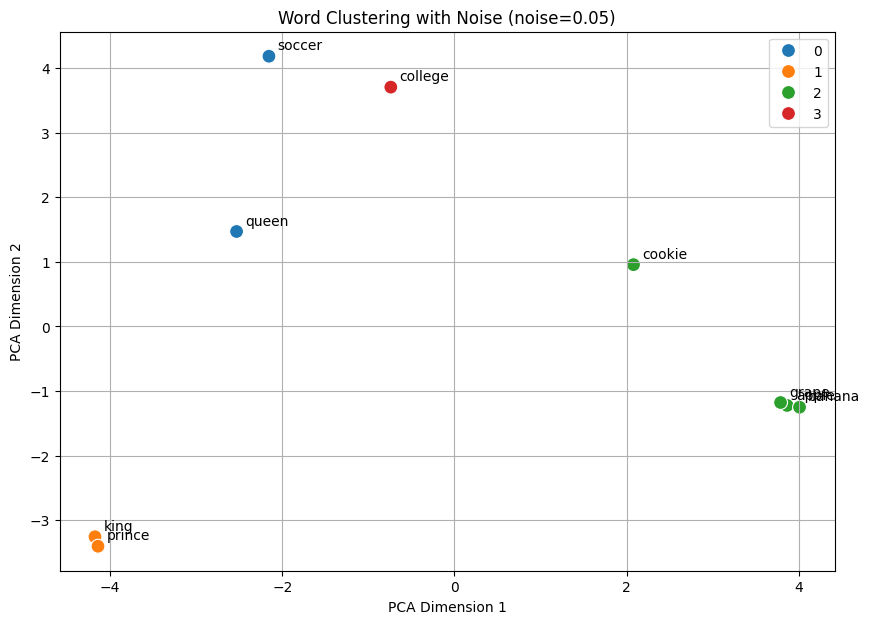

In [15]:
#code with noise
# 📦 Imports
import os
os.environ["OMP_NUM_THREADS"] = "1"

import spacy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
import pandas as pd

# 🧠 Load spaCy model
nlp = spacy.load("en_core_web_md")

# ✍️ Words
words = ["apple", "banana", "grape", "king", "queen", "prince", "soccer", "cookie", "college"]

# 🔢 Original word vectors
word_vectors = np.array([nlp(word).vector for word in words])

# ⚙️ Baseline clustering (no noise)
k = 4
kmeans_clean = KMeans(n_clusters=k, random_state=0, n_init="auto")
labels_clean = kmeans_clean.fit_predict(word_vectors)

# ---------------------------------------------------
# 🔊 Add noise to embeddings
# ---------------------------------------------------
noise_level = 0.05   # adjust this to test robustness
noise = np.random.normal(0, noise_level, word_vectors.shape)

noisy_vectors = word_vectors + noise

# ⚙️ Cluster again with noisy vectors
kmeans_noisy = KMeans(n_clusters=k, random_state=0, n_init="auto")
labels_noisy = kmeans_noisy.fit_predict(noisy_vectors)

# ---------------------------------------------------
# 📊 Compare cluster similarity
# ---------------------------------------------------
ari_score = adjusted_rand_score(labels_clean, labels_noisy)
print(f"Similarity between clean and noisy clustering (ARI): {ari_score:.3f}")

# ---------------------------------------------------
# 📉 PCA Visualization
# ---------------------------------------------------
pca = PCA(n_components=2)
points_2d = pca.fit_transform(noisy_vectors)

df = pd.DataFrame({
    "Word": words,
    "Cluster (Noisy)": labels_noisy,
    "PCA_1": points_2d[:,0],
    "PCA_2": points_2d[:,1]
})

print("\n📊 Cluster Assignments with Noise:")
print(df)

# ---------------------------------------------------
# 🎨 Plot
# ---------------------------------------------------
plt.figure(figsize=(10,7))
sns.scatterplot(x=points_2d[:,0], y=points_2d[:,1], hue=labels_noisy, palette="tab10", s=100)

for i, word in enumerate(words):
    plt.text(points_2d[i,0]+0.1, points_2d[i,1]+0.1, word)

plt.title(f"Word Clustering with Noise (noise={noise_level})")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()